<div style="text-align: center;" >
<h1 style="margin-top: 0.2em; margin-bottom: 0.1em;">Assignment 3</h1>
<h4 style="margin-top: 0.7em; margin-bottom: 0.3em; font-style:italic">Commit your solutions to GitHub until June 21, 23:59</h4>
</div>
<br>

## Part 1 
## Sentiment Evaluation of Twitter and YouTube Data

### Tasks

1. Install packages and load evaluation datasets with Google NLP scores
2. Run VADER over evaluation texts
3. Run BERT over evaluation texts
4. Evaluate against sentiment annotations and compare with Google NLP

### Install requirements. 

The following cell contains all the necessary dependencies needed for this task. If you run the cell everything will be installed. 

* [`vaderSentiment`](https://github.com/cjhutto/vaderSentiment) is a Python package for a Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text.
* [`transformers`](https://huggingface.co/) is a Python package for creating and working with transformers. [Here](https://huggingface.co/docs) is the documentation of `transformers`.
* [`torch`](https://pytorch.org/) is a Python machine learning framework. We need this here for `transformers` since this package uses internally `torch`. [Here](https://pytorch.org/docs/stable/index.html) is the documentation of `torch`.
* [`pandas`](https://pandas.pydata.org/docs/index.html) is a Python package for creating and working with tabular data. [Here](https://pandas.pydata.org/docs/reference/index.html) is the documentation of `pandas`.

In [8]:
"""
! pip install vaderSentiment
! pip install transformers
! pip install torch
! pip install pandas
"""

'\n! pip install vaderSentiment\n! pip install transformers\n! pip install torch\n! pip install pandas\n'

You may need to restart the Kernel after installing the dependencies!

### Import requirements
The cell below imports all necessary dependancies. Make sure they are installed (see cell above).

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline

from sklearn.metrics import accuracy_score

### Exercise 1: Load evaluation datasets and Google NLP scores

#### 1.1 Load datasets
First read the Twitter and Youtube Comments CSV files (`Twitter-Sentiment.csv` and `YouTubeComments-Sentiment.csv`) and save them in a pandas Dataframe.

In [10]:
df_tw = pd.read_csv('data/Twitter-Sentiment.csv')
df_tw.head(5)

,label,text,googleScore
0,Positive,?RT @justinbiebcr: The bigger the better....if...,0.3
1,Positive,"Listening to the ""New Age"" station on @Slacker...",0.2
2,Neutral,I favorited a YouTube video -- Drake and Josh ...,0.0
3,Positive,i didnt mean knee high I ment in lengt it goes...,0.8
4,Neutral,I wana see the vid Kyan,0.0


In [11]:
df_yt = pd.read_csv('data/YouTubeComments-Sentiment.csv')
df_yt.head(5)

,label,text,googleScore
0,Negative,when the time comes for all to know it will be...,0.1
1,Neutral,@princessofportk The first are a pair of devil...,0.1
2,Neutral,I gotta feeling they partlishly took it off fo...,-0.3
3,Positive,"As we look at ways to be relevant, here is a g...",0.7
4,Neutral,"Not a lot of ""removing"" going on here... bucke...",-0.3


### Exercise 2: Run VADER over evaluation texts *(2 points)*

#### 2.1 Run VADER over the first tweet

In this task you should use VADER for sentiment analysis. For this we use the `vaderSentiment` package. You first have to instantiate a new `SentimentIntensityAnalyzer` and use the `polarity_scores` method of it for the analysis. Apply this for the first tweet. Is it a good classification?

[Here](https://github.com/cjhutto/vaderSentiment) under 'Code Examples' you can find some example code how to use this package.

In [12]:
# instantiate 
analyzer = SentimentIntensityAnalyzer()

# use polarity_scores
sentiment_scores = analyzer.polarity_scores(df_tw.iloc[0].get("text"))
sentiment_scores

{'neg': 0.0, 'neu': 0.853, 'pos': 0.147, 'compound': 0.2263}

The tweet was "'?RT @justinbiebcr: The bigger the better....if you know what I mean ;)'".</br>
This sentence does not include obvious negative or positive word.
The neutral score was high, which is reasonable.

#### 2.2 Run VADER over each text

Now use VADER for all the text data of the Twitter and the Youtube dataframe. Create a new column in the dataframes called `VADER_compound` where you save the `compound` result (look at the output dictonary of the `polarity_scores` method).

*Important: Make sure `compound` is a float*

In [13]:
# For twitter data
# creating the mew column that includes compound result
df_tw["VADER_compound"] = [analyzer.polarity_scores(tweet).get("compound") for tweet in df_tw["text"]]

# changing the data type of VADER_compound column into float
df_tw["VADER_compound"] = df_tw["VADER_compound"].astype(float)


# For Youtube data
# creating the mew column that includes compound result
df_yt["VADER_compound"] = [analyzer.polarity_scores(comment).get("compound") for comment in df_yt["text"]]

# changing the data type of VADER_compound column into float
df_yt["VADER_compound"] = df_yt["VADER_compound"].astype(float)

#### 2.3 VADER as a classifier

To get the three Classes `Positive`, `Negative` and `Neutral` we use the compound score with the following thresholds:

* `compound > 0.5`: `"Positive"`
* `compound < -0.5`: `"Negative"`
* `else`: `"Neutral"`

Create a new column called `VADER_class` which contains the three computed classes.

In [14]:
# twitter
df_tw["VADER_class"] = ["Positive" if d > 0.5 else "Negative" if d < -0.5 else "Neutral" for d in df_tw["VADER_compound"]]

# youtube
df_yt["VADER_class"] = ["Positive" if d > 0.5 else "Negative" if d < -0.5 else "Neutral" for d in df_yt["VADER_compound"]]

### Exercise 3: Use a BERT based model for sentiment analysis *(2 points)*

#### 3.1 BERT
BERT (Bidirectional Encoder Representation from Transformers) is a machine learning technique for natural language processing. There are already pretrained models available in the `transformers` package. You can look [here](https://huggingface.co/models?sort=downloads&search=sentiment) and choose a model for the next tasks. (We suggest [this](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest) (`"cardiffnlp/twitter-roberta-base-sentiment-latest"`) model, but you can use any available, just make sure it is suitable for sentiment analysis).

First create a `pipeline` where you set your model by the `model` keyword argument. You can then use this method to pass text which should be classified. [Here](https://huggingface.co/blog/sentiment-analysis-python#2-how-to-use-pre-trained-sentiment-analysis-models-with-python) is a tutorial how to use this.

As before save the classes in a new column 'BERT_class'. The call to your pipeline returns a dictionary where there is a key `label` which contains already the `positive`, `negative` or `neutral` class (Be aware that this is based on the model you choose, and might be different from the labels in the dataset. If that's the case you have to rename them to match the target labels).

***Hint: The classification of the entire sample can take a couple of minutes. Make sure to save the labeled dataset in a csv file so that you don't need to rerun the classification the next time you run your notebook.***

In [15]:
# Hint -> loading roberta as a pipline
sentiment_pipeline = pipeline(model="cardiffnlp/twitter-roberta-base-sentiment-latest", tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest")

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [16]:
# Hint -> using a pipline for classification
sentiment_pipeline('Today is a great day!')

[{'label': 'positive', 'score': 0.9866099953651428}]

In [17]:
# twitter
df_tw["BERT_class"] = df_tw["text"].apply(lambda x: sentiment_pipeline(x)[0]['label'])

# youtube
df_yt["BERT_class"] = df_yt["text"].apply(lambda x: sentiment_pipeline(x)[0]['label'])

In [18]:
# The initial letters of each word in the BERT_class change into capital letters

df_tw['BERT_class'] = df_tw['BERT_class'].str.capitalize()
df_yt['BERT_class'] = df_yt['BERT_class'].str.capitalize()

### Exercise 4: Evaluate against sentiment annotations and compare with Google NLP *(4 points)*

#### 4.1 Convert GoogleNLP scores to classes

As with VADER and BERT, compute classes from the GoogleNLP score, which is given in the column `googleScore`. For this use following thresholds:

* `googleScore > 0.3`: `"Positive"`
* `googleScore < -0.3`: `"Negative"`
* `else`: `"Neutral"`

Save the classes in a new column named `GoogleNLP_class`.


In [19]:
# twitter
df_tw["GoogleNLP_class"] = ["Positive" if d > 0.3 else "Negative" if d < -0.3 else "Neutral" for d in df_tw["googleScore"]]

# youtube
df_yt["GoogleNLP_class"] = ["Positive" if d > 0.3 else "Negative" if d < -0.3 else "Neutral" for d in df_yt["googleScore"]]

In [20]:
# save the data
df_tw.to_csv("Twitter_label.csv", index=False)
df_yt.to_csv("YouTube_label.csv", index=False)

#### 4.2 Evaluate on Twitter

First, let's calculate the accuracy for all three classifiers on the Twitter and Youtube data, print the results.

In [21]:
# twitter
# Calculate accuracy for VADER
tw_vader_accuracy = accuracy_score(df_tw['label'], df_tw['VADER_class'])

# Calculate accuracy for BERT
tw_bert_accuracy = accuracy_score(df_tw['label'], df_tw['BERT_class'])

# google score
tw_googleScore_accuracy = accuracy_score(df_tw['label'], df_tw['GoogleNLP_class'])


# youtube
# Calculate accuracy for VADER
yt_vader_accuracy = accuracy_score(df_yt['label'], df_yt['VADER_class'])

# Calculate accuracy for BERT
yt_bert_accuracy = accuracy_score(df_yt['label'], df_yt['BERT_class'])

# google score
yt_googleScore_accuracy = accuracy_score(df_yt['label'], df_yt['GoogleNLP_class'])


In [22]:
print(
    f"Twitter dataframe\n"
    f"Accuracy value in positive class for VADER classifier: {tw_vader_accuracy}\n"
    f"Accuracy value in positive class for BERT classifier: {tw_bert_accuracy}\n"
    f"Accuracy value in positive class for GoogleNLP classifier: {tw_googleScore_accuracy}"
)


Twitter dataframe
Accuracy value in positive class for VADER classifier: 0.6861487289142314
Accuracy value in positive class for BERT classifier: 0.6348301259206462
Accuracy value in positive class for GoogleNLP classifier: 0.6711808030411024


In [23]:
print(
    f"YouTube dataframe\n"
    f"Accuracy value in positive class for VADER classifier: {yt_vader_accuracy}\n"
    f"Accuracy value in positive class for BERT classifier: {yt_bert_accuracy}\n"
    f"Accuracy value in positive class for GoogleNLP classifier: {yt_googleScore_accuracy}"
)


YouTube dataframe
Accuracy value in positive class for VADER classifier: 0.6592772547828728
Accuracy value in positive class for BERT classifier: 0.7433950804737322
Accuracy value in positive class for GoogleNLP classifier: 0.6595809292438506


Next calculate the precision of the `"Positive"` class for the Twitter and Youtube data.
This is calculated as follows:
$$
\begin{align}
    precision = \frac{TP}{TP + FP}
\end{align}
$$
*Note: Here the Positive samples are the one with the class-label `"Positive"`*

In [24]:
def precision_positive(label, column):
    """
    calculating precision
  
    parameters:
        label: list, the correct label
        column: list, the column that you want to know precision value
    
    return 
        precision value, which is the float
    """
    
    # the number of the true positive
    tp = ((label == "Positive") & (column == "Positive")).sum()
    
    # the number of the false positive
    fp = ((label != "Positive") & (column == "Positive")).sum()
    
    # calculating the precision value
    precision_value = tp / (tp + fp)
    
    return precision_value




In [25]:


# run the function for the twitter dataframe
tw_vader_precision_positive = precision_positive(df_tw["label"], df_tw["VADER_class"])
tw_bert_precision_positive = precision_positive(df_tw["label"], df_tw["BERT_class"])
tw_googleScore_precision_positive = precision_positive(df_tw["label"], df_tw["GoogleNLP_class"])

# run the function for the youtube dataframe
yt_vader_precision_positive = precision_positive(df_yt["label"], df_yt["VADER_class"])
yt_bert_precision_positive = precision_positive(df_yt["label"], df_yt["BERT_class"])
yt_googleScore_precision_positive = precision_positive(df_yt["label"], df_yt["GoogleNLP_class"])


In [26]:
print(
    f"Twitter dataframe\n"
    f"Precision value in positive class for VADER classifier: {tw_vader_precision_positive}\n"
    f"Precision value in positive class for BERT classifier: {tw_bert_precision_positive}\n"
    f"Precision value in positive class for GoogleNLP classifier: {tw_googleScore_precision_positive}"
)


Twitter dataframe
Precision value in positive class for VADER classifier: 0.3555370524562864
Precision value in positive class for BERT classifier: 0.357761492338441
Precision value in positive class for GoogleNLP classifier: 0.3350357507660878


In [27]:
print(
    f"YouTube dataframe\n"
    f"Precision value in positive class for VADER classifier: {yt_vader_precision_positive}\n"
    f"Precision value in positive class for BERT classifier: {yt_bert_precision_positive}\n"
    f"Precision value in positive class for GoogleNLP classifier: {yt_googleScore_precision_positive}"
)


YouTube dataframe
Precision value in positive class for VADER classifier: 0.7203791469194313
Precision value in positive class for BERT classifier: 0.7636594663278272
Precision value in positive class for GoogleNLP classifier: 0.7719594594594594


Now calculate the recall score. This is done by:
$$
\begin{align}
    recall = \frac{TP}{TP + FN}
\end{align}
$$
*Note: Here the Positive samples are the one with the the class-label `"Positive"`*

In [28]:
# making function
def recall_positive(label, column):
  """
  calculating recall
  
  parameters:
    label: list, the correct label
    column: list, the column that you want to know recall value
    
  return 
  recall value, which is the float
  """
    
  # the number of the true positive
  true_positive = ((label == "Positive") & (column == "Positive")).sum()

  # the number of the false negative
  false_negative = ((label == "Positive") & (column != "Positive")).sum()
  
  # calculating the precision value
  recall_value = true_positive / (true_positive + false_negative)
  
  return recall_value



In [29]:
# run the function for the twitter dataframe
tw_vader_recall_positive = recall_positive(df_tw["label"], df_tw["VADER_class"])
tw_bert_recall_positive = recall_positive(df_tw["label"], df_tw["BERT_class"])
tw_googleScore_recall_positive = recall_positive(df_tw["label"], df_tw["GoogleNLP_class"])

# run the function for the youtube dataframe
yt_vader_recall_positive = recall_positive(df_yt["label"], df_yt["VADER_class"])
yt_bert_recall_postive = recall_positive(df_yt["label"], df_yt["BERT_class"])
yt_googleScore_recall_postive = recall_positive(df_yt["label"], df_yt["GoogleNLP_class"])

In [30]:
print(  
    f"Twitter dataframe\n"
    f"Recall value in positive class for VADER classifier: {tw_vader_recall_positive}\n"
    f"Recall value in positive class for BERT classifier: {tw_bert_recall_positive}\n"
    f"Recall value in positive class for GoogleNLP classifier: {tw_googleScore_recall_positive}"
)


Twitter dataframe
Recall value in positive class for VADER classifier: 0.727427597955707
Recall value in positive class for BERT classifier: 0.9148211243611585
Recall value in positive class for GoogleNLP classifier: 0.5587734241908007


In [31]:
print(
    f"YouTube dataframe\n"
    f"Recall value in positive class for VADER classifier: {tw_vader_recall_positive}\n"
    f"Recall value in positive class for BERT classifier: {tw_bert_recall_positive}\n"
    f"Recall value in positive class for GoogleNLP classifier: {tw_googleScore_recall_positive}"
)


YouTube dataframe
Recall value in positive class for VADER classifier: 0.727427597955707
Recall value in positive class for BERT classifier: 0.9148211243611585
Recall value in positive class for GoogleNLP classifier: 0.5587734241908007


Calculate the Recall and the Precision score now also for the negative class. 

The Precision is calculated as:
$$
\begin{align}
    precision = \frac{TP}{TP + FP}
\end{align}
$$
*Note: Here the Positive samples are the one with the the class-label `"Negative"`*

And the Recall is calculated as:
$$
\begin{align}
    recall = \frac{TP}{TP + FN}
\end{align}
$$
*Note: Here the Positive samples are the one with the the class-label `"Negative"`*

In [32]:
# making function 
def precision_negative(label, column):
    """
    calculating precision
  
    parameters:
        label: list, the correct label
        column: list, the column that you want to know precision value
    
    return 
        precision value, which is the float
    """
    # the number of the true positive
    tp = ((label == "Negative") & (column == "Negative")).sum()
    
    # the number of the false positive
    fp = ((label != "Negative") & (column == "Negative")).sum()
    
    # calculating the precision value
    precision_value = tp / (tp + fp)
    
    return precision_value




In [33]:
# run the function for the twitter dataframe
tw_vader_precision_negative = precision_negative(df_tw["label"], df_tw["VADER_class"])
tw_bert_precision_negative = precision_negative(df_tw["label"], df_tw["BERT_class"])
tw_googleScore_precision_negative = precision_negative(df_tw["label"], df_tw["GoogleNLP_class"])

# run the function for the youtube dataframe
yt_vader_precision_negative = precision_negative(df_yt["label"], df_yt["VADER_class"])
yt_bert_precision_negative = precision_negative(df_yt["label"], df_yt["BERT_class"])
yt_googleScore_precision_negative = precision_negative(df_yt["label"], df_yt["GoogleNLP_class"])


In [34]:
print(  
    f"Twitter dataframe\n"
    f"Precision value in negative class for VADER classifier: {tw_vader_precision_negative}\n"
    f"Precision value in negative class for BERT classifier: {tw_bert_precision_negative}\n"
    f"Precision value in negative class for GoogleNLP classifier: {tw_googleScore_precision_negative}"
)


Twitter dataframe
Precision value in negative class for VADER classifier: 0.39941690962099125
Precision value in negative class for BERT classifier: 0.38235294117647056
Precision value in negative class for GoogleNLP classifier: 0.3395225464190981


In [35]:
print(  
    f"YouTube dataframe\n"
    f"Precision value in negative class for VADER classifier: {yt_vader_precision_negative}\n"
    f"Precision value in negative class for BERT classifier: {yt_bert_precision_negative}\n"
    f"Precision value in negative class for GoogleNLP classifier: {yt_googleScore_precision_negative}"
)


YouTube dataframe
Precision value in negative class for VADER classifier: 0.6126984126984127
Precision value in negative class for BERT classifier: 0.5736842105263158
Precision value in negative class for GoogleNLP classifier: 0.5661375661375662


In [36]:
# making function
def recall_negative(label, column):
  """
  calculating recall
  
  parameters:
    label: list, the correct label
    column: list, the column that you want to know recall value
    
  return 
  recall value, which is the float
  """
    
  # the number of the true positive
  true_positive = ((label == "Negative") & (column == "Negative")).sum()

  # the number of the false negative
  false_negative = ((label == "Negative") & (column != "Negative")).sum()
  
  # calculating the precision value
  recall_value = true_positive / (true_positive + false_negative)
  
  return recall_value

In [37]:
# run the function for the twitter dataframe
tw_vader_recall_negative = recall_negative(df_tw["label"], df_tw["VADER_class"])
tw_bert_recall_negative = recall_negative(df_tw["label"], df_tw["BERT_class"])
tw_googleScore_recall_negative = recall_negative(df_tw["label"], df_tw["GoogleNLP_class"])

# run the function for the youtube dataframe
yt_vader_recall_negative = recall_negative(df_yt["label"], df_yt["VADER_class"])
yt_bert_recall_negative = recall_negative(df_yt["label"], df_yt["BERT_class"])
yt_googleScore_recall_negative = recall_negative(df_yt["label"], df_yt["GoogleNLP_class"])

In [38]:
print(  
    f"Twitter dataframe\n"
    f"Recall value in negative class for VADER classifier: {tw_vader_recall_negative}\n"
    f"Recall value in negative class for BERT classifier: {tw_bert_recall_negative}\n"
    f"Recall value in negative class for GoogleNLP classifier: {tw_googleScore_recall_negative}"
)


Twitter dataframe
Recall value in negative class for VADER classifier: 0.35958005249343833
Recall value in negative class for BERT classifier: 0.8188976377952756
Recall value in negative class for GoogleNLP classifier: 0.3359580052493438


In [39]:
print(  
    f"YouTube dataframe\n"
    f"Recall value in negative class for VADER classifier: {yt_vader_recall_negative}\n"
    f"Recall value in negative class for BERT classifier: {yt_bert_recall_negative}\n"
    f"Recall value in negative class for GoogleNLP classifier: {yt_googleScore_recall_negative}"
)


YouTube dataframe
Recall value in negative class for VADER classifier: 0.36007462686567165
Recall value in negative class for BERT classifier: 0.8134328358208955
Recall value in negative class for GoogleNLP classifier: 0.39925373134328357


Last, calculate the [F1 score](https://towardsdatascience.com/the-f1-score-bec2bbc38aa6) of the positive and negative class for each classifier and dataset. The F1 score is calculated as:

$$
\begin{align}
    F_1 = 2 * \frac{precision * recall}{precision + recall}
\end{align}
$$

In [40]:
# F1 score for the postive class
def f1_score_positive(label, column):
    f1 = 2 * precision_positive(label, column) * recall_positive(label, column) / (precision_positive(label, column) + recall_positive(label, column))
    return f1

# F1 score for the negative class
def f1_score_negative(label, column):
    f1 = 2 * precision_negative(label, column) * recall_negative(label, column) / (precision_negative(label, column) + recall_negative(label, column))
    return f1

In [41]:
# twitter
sentiment_class = ["VADER_class", "BERT_class", "GoogleNLP_class"]
f1_scores_positive_tw =  [f1_score_positive(df_tw["label"], df_tw[i]) for i in sentiment_class]
f1_scores_negative_tw =  [f1_score_negative(df_tw["label"], df_tw[i]) for i in sentiment_class]

# youtube
sentiment_class = ["VADER_class", "BERT_class", "GoogleNLP_class"]
f1_scores_positive_yt =  [f1_score_positive(df_yt["label"], df_yt[i]) for i in sentiment_class]
f1_scores_negative_yt =  [f1_score_negative(df_yt["label"], df_yt[i]) for i in sentiment_class]


In [88]:
print(f"For Twitter dataframe, the F1 scores in positive class are:\n")
for i, j in zip(sentiment_class, f1_scores_positive_tw):
    print(
        f"{i}: {j}"
    )

For Twitter dataframe, the F1 scores in positive class are:

VADER_class: 0.47762863534675615
BERT_class: 0.514367816091954
GoogleNLP_class: 0.4189016602809706


In [89]:
print(f"For Twitter dataframe, the F1 scores in negative class are:\n")
for i, j in zip(sentiment_class, f1_scores_negative_tw):
    print(
        f"{i}: {j}"
    )

For Twitter dataframe, the F1 scores in negative class are:

VADER_class: 0.3784530386740331
BERT_class: 0.5213032581453635
GoogleNLP_class: 0.33773087071240104


In [90]:
print(f"For YouTube dataframe, the F1 scores in positive class are:\n")
for i, j in zip(sentiment_class, f1_scores_positive_yt):
    print(
        f"{i}: {j}"
    )

For YouTube dataframe, the F1 scores in positive class are:

VADER_class: 0.7072508724311749
BERT_class: 0.8326983027364045
GoogleNLP_class: 0.7320784941930317


In [91]:
print(f"For YouTube dataframe, the F1 scores in neagtive class are:\n")
for i, j in zip(sentiment_class, f1_scores_negative_yt):
    print(
        f"{i}: {j}"                                                                                   
    )

For YouTube dataframe, the F1 scores in neagtive class are:

VADER_class: 0.45358401880141014
BERT_class: 0.6728395061728395
GoogleNLP_class: 0.4682713347921225


### Exercise 5: Comparison *(2 points)*
* What was the best performing method for Youtube? Did that fit your expectations?


In [46]:
print(f"The best performing method for youtube in the positive class: {sentiment_class[f1_scores_positive_yt.index(max(f1_scores_positive_yt))]}")
print(f"The best performing method for youtube in the negative class: {sentiment_class[f1_scores_negative_yt.index(max(f1_scores_negative_yt))]}")

The best performing method for youtube in the positive class: BERT_class
The best performing method for youtube in the negative class: BERT_class


accuracy
recall low  

I expected that the BERT classifier was the best since this classifier is most advanced.    
My expectation was fitted.  
</br>


* What was the best performing method for Twitter? Did that fit your expectations?


In [47]:
print(f"The best performing method for twitter in the positive class: {sentiment_class[f1_scores_positive_tw.index(max(f1_scores_positive_tw))]}")
print(f"The best performing method for twitter in the negative class: {sentiment_class[f1_scores_negative_tw.index(max(f1_scores_negative_tw))]}") 

The best performing method for twitter in the positive class: BERT_class
The best performing method for twitter in the negative class: BERT_class


Similarly, I expected that the BERT classifier was the best since this classifier is most advanced.  
My expectation was fitted.

* Do you observe any differences between prediction of positive and negative sentiment? What is the role of the imbalance between postive and negative classes in the calculation of accuracy?




Accuracy paradox can happen.
For example, if the data is biased and 95% of the total classes are negative, one can get 95% accuracy by simply predicting all as negative. However, this means that you are not predicting any positive classes at all.  
</br>
Not only accuracy, but also precision, recall f1 score are useful. Presicion is used when the cost of false positives is high, e.g. spam detection. Recall is useful in the case where the cost of false negatives is high, e.g. security system. F1 score is used when there is a need for a balance between precision and recall, e.g. text classification.

## Part 2 - Emotion Detection

### Exercise 6 *(4 points)*

In the following exercise you will use the emotion classification model [LEIA](https://huggingface.co/LEIA/LEIA-base) to classify the emotion of the sentences in the [enISEAR dataset](https://www.romanklinger.de/data-sets/). You can read more about the `LEIA-base` model in the [documentation](https://huggingface.co/LEIA/LEIA-base) and learn about the implementation details from this [paper](https://arxiv.org/abs/2304.10973).

#### 6.1 LEIA introduction
* Load the `LEIA-base` model and tokenize either as a [pipeline](https://huggingface.co/docs/transformers/main_classes/pipelines), or you can load the model and the tokenizer [directly](https://huggingface.co/docs/transformers/autoclass_tutorial) and implement the classification steps by yourself. LEIA only accepts sentences with up to 128 tokens. Make sure that your tokenizer [truncates](https://huggingface.co/docs/transformers/pad_truncation) longer sentences to this lenght to avoid errors.
* What are the possible labels the model can predict?
* Input the sentence `Today is a great day.` to the model, and predict the emotion of the sentence.

In [48]:
from transformers import pipeline
pipe = pipeline("text-classification", model="LEIA/LEIA-base", truncation=True, max_length=126)
result = pipe('Today is a great day!')
result 

[{'label': 'Happiness', 'score': 0.8113287091255188}]

#### 6.2 enISEAR dataset
* Load the enISEAR dataset.
* What are the possible labels in the dataset? (the `Prior_Emotion` column stores the actual ground-truth label)
* The last 7 columns store the number of annotators who chose the given emotion (e.g. if you have the value 3 in the column 'Anger', this means that 3 annotators believed that the sentence in the row expresses Anger). Create a new column `Annotator_Majority_Label`, which stores the emotion with the highest annotator score (i.e. the emotion the highest number of annotators chose for the given sentence).
* What percent of the sentences were correctly classified by the (majority vote of the) annotators?

In [49]:
df_isear = pd.read_csv('data/enISEAR.tsv', sep='\t')
df_isear.head(5)

,Sentence_id,Prior_Emotion,Sentence,Temporal_Distance,Intensity,Duration,Gender,City,Country,Worker_id,Time,Anger,Disgust,Fear,Guilt,Joy,Sadness,Shame
0,271,Fear,"I felt ... when my 2 year old broke her leg, a...",Y,Vi,Dom,Ml,Bristol,GBR,87,11/28/2018 00:58:52,0,0,0,1,0,3,1
1,597,Shame,I felt ... one Christmas as one of our patient...,Y,I,Dom,Fl,Dulwich,GBR,86,11/26/2018 06:52:02,1,0,0,4,0,0,0
2,282,Guilt,I felt ... because I could not help a friend w...,M,Mi,Dom,Fl,Linlithgow,GBR,83,11/21/2018 18:45:00,0,0,0,4,0,1,0
3,171,Disgust,I felt ... when I read that hunters had killed...,Y,Mi,H,Ml,Bristol,GBR,87,11/28/2018 00:55:11,3,0,0,0,0,2,0
4,509,Sadness,I felt ... when my Gran passed away.,Y,Vi,Dom,Fl,Stoke-on-trent,GBR,92,11/26/2018 09:23:38,0,0,0,0,0,5,0


In [50]:
# What are the possible labels in the dataset?
labels = df_isear["Prior_Emotion"].unique()
labels

array(['Fear', 'Shame', 'Guilt', 'Disgust', 'Sadness', 'Anger', 'Joy'],
      dtype=object)

In [51]:
# getting the last 7 columns
last_7_columns = df_isear.iloc[:, -7:]

# Create a new column `Annotator_Majority_Label`, which stores the emotion with the highest annotator score
df_isear["Annotator_Majority_Label"] = last_7_columns.idxmax(axis=1)

In [52]:
df_isear

,Sentence_id,Prior_Emotion,Sentence,Temporal_Distance,Intensity,Duration,Gender,City,Country,Worker_id,Time,Anger,Disgust,Fear,Guilt,Joy,Sadness,Shame,Annotator_Majority_Label
0,271,Fear,"I felt ... when my 2 year old broke her leg, a...",Y,Vi,Dom,Ml,Bristol,GBR,87,11/28/2018 00:58:52,0,0,0,1,0,3,1,Sadness
1,597,Shame,I felt ... one Christmas as one of our patient...,Y,I,Dom,Fl,Dulwich,GBR,86,11/26/2018 06:52:02,1,0,0,4,0,0,0,Guilt
2,282,Guilt,I felt ... because I could not help a friend w...,M,Mi,Dom,Fl,Linlithgow,GBR,83,11/21/2018 18:45:00,0,0,0,4,0,1,0,Guilt
3,171,Disgust,I felt ... when I read that hunters had killed...,Y,Mi,H,Ml,Bristol,GBR,87,11/28/2018 00:55:11,3,0,0,0,0,2,0,Anger
4,509,Sadness,I felt ... when my Gran passed away.,Y,Vi,Dom,Fl,Stoke-on-trent,GBR,92,11/26/2018 09:23:38,0,0,0,0,0,5,0,Sadness
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,579,Shame,I felt ... that the neighbours in the small vi...,Y,Vi,Dom,Fl,Dulwich,GBR,86,11/25/2018 16:32:23,1,1,0,0,0,0,3,Shame
997,593,Shame,I feel ... because I behave in a way that I am...,W,Mi,H,Fl,Tunbridge Wells,GBR,122,11/24/2018 11:11:15,0,0,0,3,0,0,2,Guilt
998,605,Shame,I felt ... because I fell over in public.,W,N,Fm,Fl,Sheffield,GBR,56,11/26/2018 17:28:12,0,0,0,0,0,0,5,Shame
999,606,Shame,I felt ... giving a cheque to the managing age...,W,I,H,Fl,Shepherds Bush,GBR,90,11/26/2018 21:26:45,0,0,0,2,0,0,3,Shame


In [53]:
# What percent of the sentences were correctly classified by the (majority vote of the) annotators?

number_correct = (df_isear["Prior_Emotion"] == df_isear["Annotator_Majority_Label"]).sum()

percent_correct = number_correct / len(df_isear)
percent_correct

0.7962037962037962

#### 6.3 Classification
* Drop the rows from the enISEAR dataset, where the `Prior_Emotion` is not one of `Fear`, `Sadness`, `Anger` or `Joy`
* Use `Leia` to classify the emotion of each remaining sentence in the dataset, and add a column `Leia_Label` to store the predicted classes
* Now remove `I felt ... ` (or variations of it) from the beginning of each sentence, and rerun the classfication. Store your results in a column named `Leia_Label_Clean`
* Where the model predicted `Happiness` or `Affection`, change the prediction to `Joy` to match the dataset's labels (for both columns -> `Leia_Label` and `Leia_Label_Clean`)

In [54]:
# drop the rows from the dataset, where the Prior_Emotion is not one of fear, sadness, anger, joy

# the list of the words 
drop_emotions = ['Shame', 'Guilt', 'Disgust']

# # drop the rows that include the above list
df_isear_drop = df_isear[~df_isear['Prior_Emotion'].isin(drop_emotions)]

In [55]:
# labeling the sentence column by LEIA

df_isear_drop["Leia_Label"] = df_isear_drop["Sentence"].apply(lambda x: pipe(x)[0]["label"])

C:\Users\Nutzer\AppData\Local\Temp\ipykernel_8668\3468211206.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_isear_drop["Leia_Label"] = df_isear_drop["Sentence"].apply(lambda x: pipe(x)[0]["label"])


In [56]:
# removing I feel and variation of it using regular expression
import re
df_isear_drop["Sentence"] = df_isear_drop["Sentence"].apply(lambda x: re.sub(r'I.{0,5}', "", x, count=1))

C:\Users\Nutzer\AppData\Local\Temp\ipykernel_8668\2315142011.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_isear_drop["Sentence"] = df_isear_drop["Sentence"].apply(lambda x: re.sub(r'I.{0,5}', "", x, count=1))


In [57]:
# showing the sentence column after removing "I feel" or variation of it
df_isear_drop["Sentence"]

0       ... when my 2 year old broke her leg, and we ...
4                          ... when my Gran passed away.
6       ... when an aeroplane I was on hit a heavy tu...
8       ... when my lover Pierre-Guillaume left me fo...
9       ... when someone hit my wife's car and drove ...
                             ...                        
989     ... when an impoverished family we know well ...
990     ... when a horse was killed in the Grand Nati...
991     ... when my college course finished as I was ...
992     ... when I saw an old man waiting alone at th...
993     ... when I saw a recent wildlife documentary ...
Name: Sentence, Length: 572, dtype: object

In [58]:
# creating the new column 
df_isear_drop["Leia_Label_Clean"] = df_isear_drop["Sentence"].apply(lambda x: pipe(x)[0]["label"])

C:\Users\Nutzer\AppData\Local\Temp\ipykernel_8668\3047345158.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_isear_drop["Leia_Label_Clean"] = df_isear_drop["Sentence"].apply(lambda x: pipe(x)[0]["label"])


In [59]:
# if value in ["Happiness", "Affection"] 
def replace_emotions(value):
    if value in ["Happiness", "Affection"]:
        return "Joy"
    return value


df_isear_drop["Leia_Label"] = df_isear_drop["Leia_Label"].apply(replace_emotions)
df_isear_drop["Leia_Label_Clean"] = df_isear_drop["Leia_Label_Clean"].apply(replace_emotions)

C:\Users\Nutzer\AppData\Local\Temp\ipykernel_8668\2925995049.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_isear_drop["Leia_Label"] = df_isear_drop["Leia_Label"].apply(replace_emotions)
C:\Users\Nutzer\AppData\Local\Temp\ipykernel_8668\2925995049.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_isear_drop["Leia_Label_Clean"] = df_isear_drop["Leia_Label_Clean"].apply(replace_emotions)


In [60]:
df_isear_drop

,Sentence_id,Prior_Emotion,Sentence,Temporal_Distance,Intensity,Duration,Gender,City,Country,Worker_id,...,Anger,Disgust,Fear,Guilt,Joy,Sadness,Shame,Annotator_Majority_Label,Leia_Label,Leia_Label_Clean
0,271,Fear,"... when my 2 year old broke her leg, and we ...",Y,Vi,Dom,Ml,Bristol,GBR,87,...,0,0,0,1,0,3,1,Sadness,Fear,Sadness
4,509,Sadness,... when my Gran passed away.,Y,Vi,Dom,Fl,Stoke-on-trent,GBR,92,...,0,0,0,0,0,5,0,Sadness,Sadness,Sadness
6,218,Fear,... when an aeroplane I was on hit a heavy tu...,Y,Vi,Sh,Ml,Prescot,GBR,63,...,0,0,5,0,0,0,0,Fear,Fear,Fear
8,553,Sadness,... when my lover Pierre-Guillaume left me fo...,M,Vi,Dom,Fl,NaN,GBR,105,...,4,0,0,0,0,1,0,Anger,Sadness,Sadness
9,58,Anger,... when someone hit my wife's car and drove ...,W,Mi,H,Ml,Bristol,GBR,87,...,5,0,0,0,0,0,0,Anger,Sadness,Sadness
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
989,536,Sadness,... when an impoverished family we know well ...,D,I,Dom,Fl,Ely,GBR,62,...,1,0,0,1,0,3,0,Sadness,Sadness,Anger
990,546,Sadness,... when a horse was killed in the Grand Nati...,Y,Mi,Fm,Ml,Chelmsford,GBR,91,...,0,1,0,0,0,4,0,Sadness,Sadness,Sadness
991,548,Sadness,... when my college course finished as I was ...,M,Mi,Dom,Ml,Prescot,GBR,63,...,0,0,0,0,0,5,0,Sadness,Sadness,Sadness
992,555,Sadness,... when I saw an old man waiting alone at th...,M,Mi,H,Ml,NaN,GBR,68,...,0,0,0,0,0,5,0,Sadness,Joy,Joy


#### 6.4 Analysis
* Compare the performance of the two approaches, with each other, as well as with the performance of the human majority using the metrics introduced in part 1 (accuracy, precision, recall, f1 score) or other metrics you find interesting. Create informative visualizations to aid the comparison.
* Discuss your results. 
* Are the models accurately predicting human emotions?
* Which approach seems to work better? Why?
* What kind of other/additional preprocessing could we perform to improve the model's predictions?

In [61]:
# making confusion matrix
from sklearn.metrics import precision_score, recall_score

def confusion_matrix(answer, predict):
    accuracy = accuracy_score(answer, predict)
    precision = precision_score(answer, predict, average= "macro")
    recall = recall_score(answer, predict, average = "macro")
    f1_value = 2 * precision * recall / (precision + recall)
    dct = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1 score": f1_value
    }
    return dct

In [62]:
annotator_results = confusion_matrix(df_isear_drop["Prior_Emotion"], df_isear_drop["Annotator_Majority_Label"])
annotator_results

c:\Users\Nutzer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'accuracy': 0.9108391608391608,
 'precision': 0.53134908085044,
 'recall': 0.5204795204795205,
 'f1 score': 0.5258581378345972}

In [63]:
leia_results = confusion_matrix(df_isear_drop["Prior_Emotion"], df_isear_drop["Leia_Label"])
leia_results

{'accuracy': 0.7674825174825175,
 'precision': 0.8148847926267282,
 'recall': 0.7674825174825175,
 'f1 score': 0.7904736505965895}

In [64]:
leia_clean_results = confusion_matrix(df_isear_drop["Prior_Emotion"], df_isear_drop["Leia_Label_Clean"])
leia_clean_results

{'accuracy': 0.7797202797202797,
 'precision': 0.8097646934276276,
 'recall': 0.7797202797202797,
 'f1 score': 0.794458537115397}

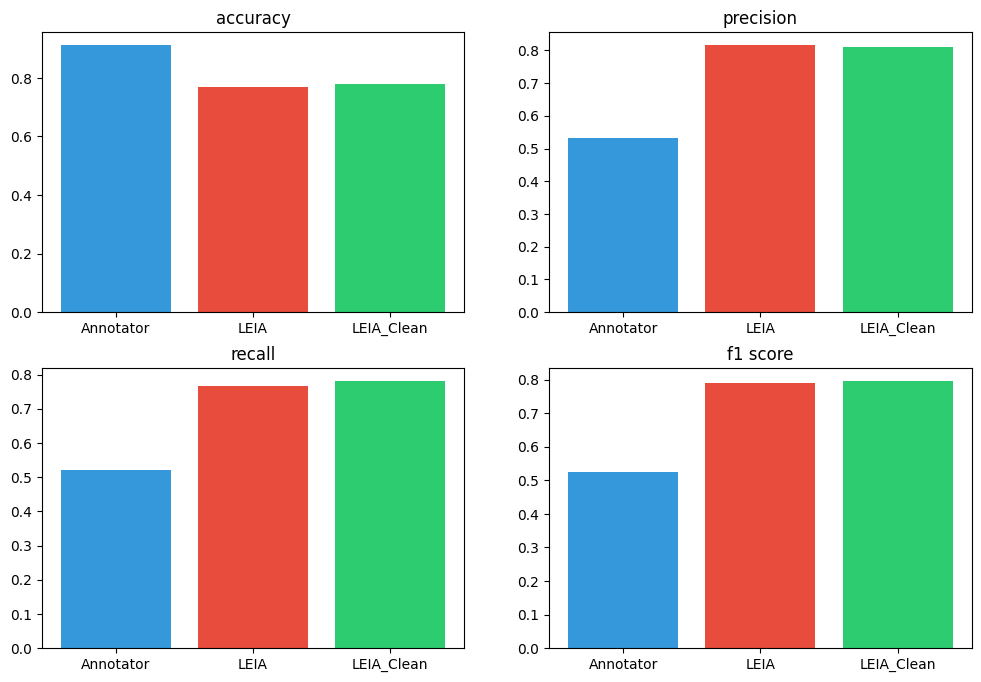

In [65]:
# visualizing in bar graphs

plt.figure(figsize=(12, 8))

# the list of label 
classifiers = ["Annotator", "LEIA", "LEIA_Clean"]

# for the graph makig the lists for accracy
accuracies = [
    annotator_results["accuracy"],
    leia_results["accuracy"],
    leia_clean_results["accuracy"],
]

# creating the graph
plt.subplot(2, 2, 1)
plt.bar(classifiers, accuracies, color=["#3498db", "#e74c3c", "#2ecc71"])
plt.title("accuracy")



# for precision
precisions = [
    annotator_results["precision"],
    leia_results["precision"],
    leia_clean_results["precision"],
]
plt.subplot(2, 2, 2)
plt.bar(classifiers, precisions, color=["#3498db", "#e74c3c", "#2ecc71"])
plt.title("precision")


# for recall
recalls = [
    annotator_results["recall"],
    leia_results["recall"],
    leia_clean_results["recall"],
]
plt.subplot(2, 2, 3)
plt.bar(classifiers, recalls, color=["#3498db", "#e74c3c", "#2ecc71"])
plt.title("recall")


# for f1 score
f1_scores = [
    annotator_results["f1 score"],
    leia_results["f1 score"],
    leia_clean_results["f1 score"]
]
plt.subplot(2, 2, 4)
plt.bar(classifiers, f1_scores, color=["#3498db", "#e74c3c", "#2ecc71"])
plt.title("f1 score")

plt.show()

* Discuss your results. 



As for accuracy, annotator approach is the best. However, considering precision, recall, and f1 score, I got LEIA approach after cleaning is the best. 

* Are the models accurately predicting human emotions?  

LEIA approach after cleaning can be considered almost accurate to predict human emotions.  
The performance of LEIA approach is slightly below the that of LEIA approach after cleaning.  
Precision, recall and F1 score of Annotator is approximately 0.5, which is not high. 

* Which approach seems to work better? Why?  

LEIA approach after cleaning seems to work better than the others, since LEIA approach is most advance, and removing the phrase "I feel" reduced the noise and made it easier to accurately determine the emotion of the sentence. 

* What kind of other/additional preprocessing could we perform to improve the model's predictions?  

Possible ways to improve performance include reducing noise by removing "," or using NLTK to remove stop words.

### Exercise 7 *(6 points)*

#### 7.1 Data annotation
* In the following exercise you will need to test emotion detection methods on data from [Vent](https://www.vent.co/), a website where users talk about their feelings. 
* On GitHub, in the `a03/data` folder you can find 2 files. First open `data_for_labeling.csv`. This file contains 100 texts. Import the data and sample 30 random texts. Remember to set a seed and save the sample to a separate csv. This is the sample, for which you are supposed to label the emotion in each sentence. Feel free to do this in the csv (i.e. in Excel). The possible classes are: 0 (Sadness), 1 (Affection), 2 (Fear), 3 (Happiness), 4 (Anger). ***Important: Make sure to upload the labeled data with your submission.***
* After you finished labeling the data load it as a pandas dataframe. Also load `data_with_labels.csv` as a dataframe, which contains the actual labels of the 100 rows of data.
* Merge the two dataframes (so that you end up with the 30 rows, you sampled. Including your labels and the ground truth), and rename the column containing your labels as `label_human`.
* Rename the class ids (0, 1, 2, ...) stored in the `label`, and `label_human` columns to the class names (Sadness, Affection, ...).

In [66]:
df_for_labeling = pd.read_csv("./data/data_for_labeling.csv")

# setting a seed
np.random.seed(42)

# sampling 
sample = df_for_labeling.sample(30, random_state=42)

# save the dataframe as csv, 
# I comment outed this code because I uploaded the file labeled by me.
#sample.to_csv("sample_df.csv", index=False)

In [67]:
df_after_label = pd.read_csv("./sample_df.csv")

In [68]:
df_after_label

,text,label_human
0,I'm so busy this weekend that I have no time t...,0
1,I don't even know what I'm doing for my birthday.,2
2,I get to go home today and I get my new phone ...,3
3,This weekend is stressing me out. I have to be...,2
4,I feel weird and empty and sad and happy and w...,2
5,You get upset when your phone doesn't work and...,1
6,I hate boys as much as I love them. 😁😘,1
7,I've never been so tired that much😑😞,4
8,I tried not to care today and I almost didn't,0
9,I want you so bad. So bad. I miss you.,0


In [69]:
# load the data_with_labels 
df_data_with_labeling = pd.read_csv("./data/data_with_labels.csv")

# sampling the dataframe 
sample2 = df_data_with_labeling.sample(30, random_state=42)

In [70]:
# merge the dataframes
merged_df = pd.merge(df_after_label, sample2)

In [71]:
# rename the class ids to class names
mapping ={
    0: "Sadness",
    1: "Affection",
    2: "Fear",
    3: "Happiness",
    4: "Anger"
}

merged_df["label"] = merged_df["label"].map(mapping)
merged_df["label_human"] = merged_df["label_human"].map(mapping)

#### 7.2 LEIA
* Use the [LEIA](https://huggingface.co/LEIA/LEIA-base) model introduced in the previous exercise to classify the sentences and store the results in a column named `label_leia`.

In [72]:
pipe = pipeline("text-classification", model="LEIA/LEIA-base")
merged_df["Leia_label"] = merged_df["text"].apply(lambda x: pipe(x)[0]["label"])

#### 7.3 Open Models from the Hugging Face Model Hub

* In the following exercise we will work with the free [Huggin Face Inference API](https://huggingface.co/docs/api-inference/en/index), an API which allows you to access many, also very powerful open AI models. Your task will be to use a [text completion](https://huggingface.co/docs/api-inference/en/quicktour) model to classify the sentences, you and LEIA labeled above (your sample of 30 rows), according to their emotion (Sadness, Affection, Fear, Happiness, Anger).

* You have to sign up for the API by creating an account on the [Hugging Face page](https://huggingface.co/join). The free version is rate limited, which should not pose a problem with the number of examples in this exercise.

* After you login, create an API key on this page in the settings: https://huggingface.co/settings/tokens


<img src="src/hf_key.png" alt="HF token" style="width: 600px;"/>

* We recommend to use [Meta-Llama-3-8B-Instruct](https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct) for this task. If you want, you can also use another, powerful recent model, but you will have to adapt the prompting format and maybe other parameters to be able to do that.

* Run the model on the texts and extract the label from the model's response (Hint: `.split("<|start_header_id|>assistant<|end_header_id|>")` can help you with that).

* Store the results in a column named `label_llama3`.

In [73]:
import time
import pandas as pd
import random
import requests

In [74]:
# Just an example with the whole (100 row) data set here
df = pd.read_csv("data/data_with_labels.csv")

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head(2)

,text,label
0,I'm so busy this weekend that I have no time t...,4
1,I don't even know what I'm doing for my birthday.,2


In [75]:
sents = df['text'].values

In [76]:
# take a look at one example text
sents[25]

'Great now my head hurts too'

In [ ]:
# enter your key here
API_TOKEN="APIKEY"

API_URL = "https://api-inference.huggingface.co/models/meta-llama/Meta-Llama-3-8B-Instruct"
headers = {"Authorization": f"Bearer {API_TOKEN}"}


# few-shot prompting llama3
def query(text):
    
    payload={
    "inputs": "<|begin_of_text|>\
    <|start_header_id|>system<|end_header_id|>\
    You are now Emotbot.\
    Emotbot answers with only one of the following words: Sadness, Affection, Fear, Happiness, Anger.\
    If Emotbot answers with anything else they have failed. Emotbot cannot fail.\
    Emotbot will be provided with short pieces of text from the website 'Vent'.\
    'Vent' is a website where users can share their feelings to an anonymous audience.\
    When writing the 'Vent' text, the authors selected 1 of the following emotions to represent what they were feeling: 'Sadness', 'Affection', 'Fear', 'Happiness', or 'Anger'.\
    Emotbot will read and analyse the text and predict which of the 5 feelings the author had selected.\
    <|eot_id|>\
    \
    <|start_header_id|>user<|end_header_id|>I hate fuckin every single person on this fuckin planet. Someone kill me pls<|eot_id|>\
    <|start_header_id|>assistant<|end_header_id|>Sadness<|eot_id|>\
    \
    <|start_header_id|>user<|end_header_id|>Best day I have had in a long time :)<|eot_id|>\
    <|start_header_id|>assistant<|end_header_id|>Happiness<|eot_id|>\
    \
    <|start_header_id|>user<|end_header_id|>boy I like called me princess He’s so precious<|eot_id|>\
    <|start_header_id|>assistant<|end_header_id|>Affection<|eot_id|>\
    \
    <|start_header_id|>user<|end_header_id|>"+text+"<|eot_id|><|start_header_id|>assistant<|end_header_id|>"
    }
    
    response = requests.post(API_URL, headers=headers, json=payload)
    return response.json()


output = query(sents[25])

output

[{'generated_text': "<|begin_of_text|>    <|start_header_id|>system<|end_header_id|>    You are now Emotbot.    Emotbot answers with only one of the following words: Sadness, Affection, Fear, Happiness, Anger.    If Emotbot answers with anything else they have failed. Emotbot cannot fail.    Emotbot will be provided with short pieces of text from the website 'Vent'.    'Vent' is a website where users can share their feelings to an anonymous audience.    When writing the 'Vent' text, the authors selected 1 of the following emotions to represent what they were feeling: 'Sadness', 'Affection', 'Fear', 'Happiness', or 'Anger'.    Emotbot will read and analyse the text and predict which of the 5 feelings the author had selected.    <|eot_id|>        <|start_header_id|>user<|end_header_id|>I hate fuckin every single person on this fuckin planet. Someone kill me pls<|eot_id|>    <|start_header_id|>assistant<|end_header_id|>Sadness<|eot_id|>        <|start_header_id|>user<|end_header_id|>Best 

In [78]:
# get the label

output[0]['generated_text'].split("<|start_header_id|>assistant<|end_header_id|>")[4]

'Sadness'

In [79]:
# create new column
merged_df["label_llama3"] = merged_df["text"].apply(lambda x: query(x)[0]['generated_text'].split("<|start_header_id|>assistant<|end_header_id|>")[4])

In [80]:
merged_df

,text,label_human,label,Leia_label,label_llama3
0,I'm so busy this weekend that I have no time t...,Sadness,Anger,Fear,Anger
1,I don't even know what I'm doing for my birthday.,Fear,Fear,Fear,Sadness
2,I get to go home today and I get my new phone ...,Happiness,Happiness,Happiness,Happiness
3,This weekend is stressing me out. I have to be...,Fear,Fear,Fear,Fear
4,I feel weird and empty and sad and happy and w...,Fear,Fear,Fear,Sadness
5,You get upset when your phone doesn't work and...,Affection,Affection,Anger,Fear
6,I hate boys as much as I love them. 😁😘,Affection,Affection,Affection,Anger
7,I've never been so tired that much😑😞,Anger,Anger,Anger,Sadness
8,I tried not to care today and I almost didn't,Sadness,Sadness,Sadness,Anger
9,I want you so bad. So bad. I miss you.,Sadness,Sadness,Sadness,Affection


#### 7.4 Comparison
* Compare the performance of the two models, with each other, as well as with the quality of your annotation using the metrics introduced in part 1 (accuracy, precision, recall, f1 score) or other metrics you find interesting. Create informative visualizations to aid the comparison.
 



In [81]:
# comparing the label with human label
human_results = confusion_matrix(merged_df["label"], merged_df["label_human"])
human_results

{'accuracy': 0.8,
 'precision': 0.8195238095238094,
 'recall': 0.8028571428571428,
 'f1 score': 0.8111048681286427}

In [82]:
# comapring the label with LEIA label
leia_results = confusion_matrix(merged_df["label"], merged_df["Leia_label"])
leia_results

{'accuracy': 0.8,
 'precision': 0.82,
 'recall': 0.7914285714285715,
 'f1 score': 0.8054609929078014}

In [83]:
# comparing the label with label_llama3
llama3_results = confusion_matrix(merged_df["label"], merged_df["label_llama3"])
llama3_results

{'accuracy': 0.5333333333333333,
 'precision': 0.54,
 'recall': 0.540952380952381,
 'f1 score': 0.54047577092511}

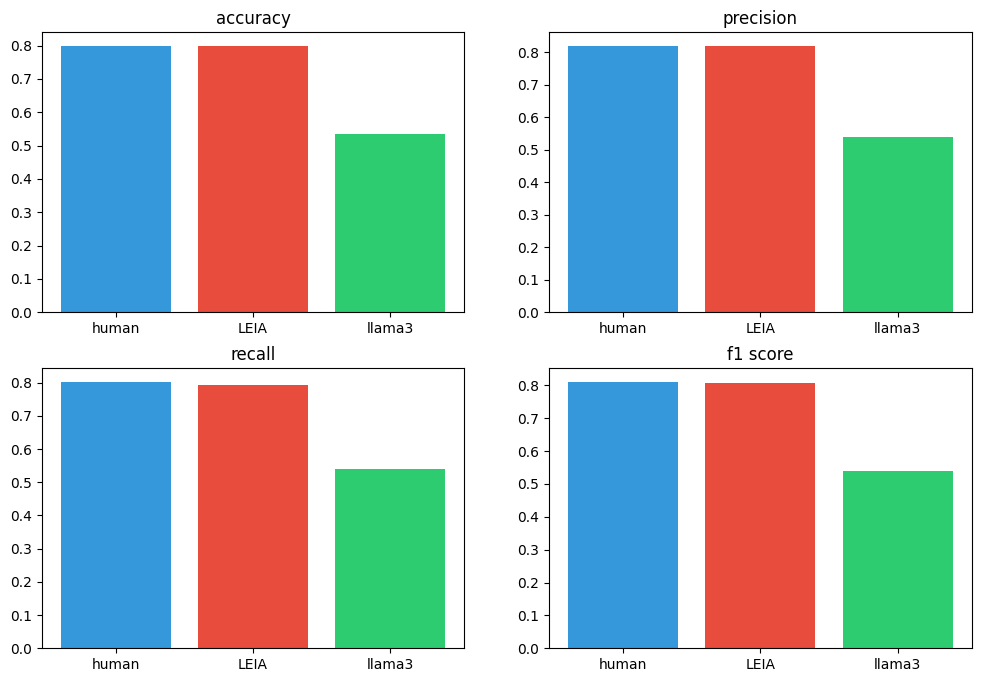

In [84]:
# visualization in bar graphs

plt.figure(figsize=(12, 8))

# the list of label 
classifiers = ["human", "LEIA", "llama3"]

# for the graph making the lists for accracy
accuracies = [
    human_results["accuracy"],
    leia_results["accuracy"],
    llama3_results["accuracy"]
    
]

# creating the graph
plt.subplot(2, 2, 1)
plt.bar(classifiers, accuracies, color=["#3498db", "#e74c3c", "#2ecc71"])
plt.title("accuracy")


# for precision
precisions = [
    human_results["precision"],
    leia_results["precision"],
    llama3_results["precision"]
]
plt.subplot(2, 2, 2)
plt.bar(classifiers, precisions, color=["#3498db", "#e74c3c", "#2ecc71"])
plt.title("precision")


# for recall
recalls = [
    human_results["recall"],
    leia_results["recall"],
    llama3_results["recall"]
]
plt.subplot(2, 2, 3)
plt.bar(classifiers, recalls, color=["#3498db", "#e74c3c", "#2ecc71"])
plt.title("recall")

# for f1 score
f1_scores = [
    human_results["f1 score"],
    leia_results["f1 score"],
    llama3_results["f1 score"]
]
plt.subplot(2, 2, 4)
plt.bar(classifiers, f1_scores, color=["#3498db", "#e74c3c", "#2ecc71"])
plt.title("f1 score")

plt.show()

[Text(0, 0.5, 'Sadness'),
 Text(0, 1.5, 'Affection'),
 Text(0, 2.5, 'Fear'),
 Text(0, 3.5, 'Happiness'),
 Text(0, 4.5, 'Anger')]

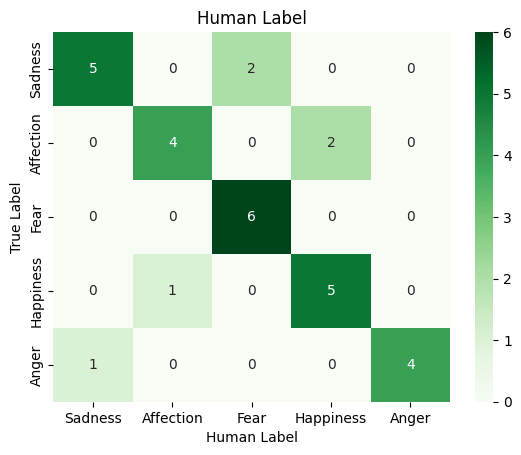

In [85]:
# creating the heatmap 
# predicted label x-axis and true label on y-axis

from sklearn.metrics import confusion_matrix
# human
matrix = confusion_matrix(merged_df["label"], merged_df["label_human"], labels=["Sadness", "Affection", "Fear", "Happiness", "Anger"])
ax = sns.heatmap(matrix, annot=True, cmap="Greens")
ax.set(title="Human Label", xlabel="Human Label", ylabel="True Label")
ax.xaxis.set_ticklabels(["Sadness", "Affection", "Fear", "Happiness", "Anger"])
ax.yaxis.set_ticklabels(["Sadness", "Affection", "Fear", "Happiness", "Anger"])





[Text(0, 0.5, 'Sadness'),
 Text(0, 1.5, 'Affection'),
 Text(0, 2.5, 'Fear'),
 Text(0, 3.5, 'Happiness'),
 Text(0, 4.5, 'Anger')]

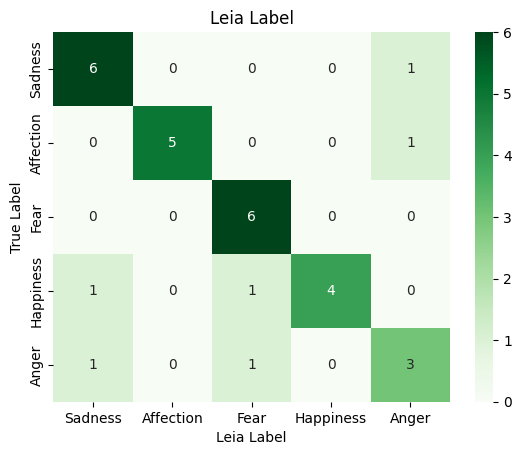

In [86]:
# leia
matrix = confusion_matrix(merged_df["label"], merged_df["Leia_label"], labels=["Sadness", "Affection", "Fear", "Happiness", "Anger"])
ax = sns.heatmap(matrix, annot=True, cmap="Greens")
ax.set(title="Leia Label", xlabel="Leia Label", ylabel="True Label")
ax.xaxis.set_ticklabels(["Sadness", "Affection", "Fear", "Happiness", "Anger"])
ax.yaxis.set_ticklabels(["Sadness", "Affection", "Fear", "Happiness", "Anger"])



[Text(0, 0.5, 'Sadness'),
 Text(0, 1.5, 'Affection'),
 Text(0, 2.5, 'Fear'),
 Text(0, 3.5, 'Happiness'),
 Text(0, 4.5, 'Anger')]

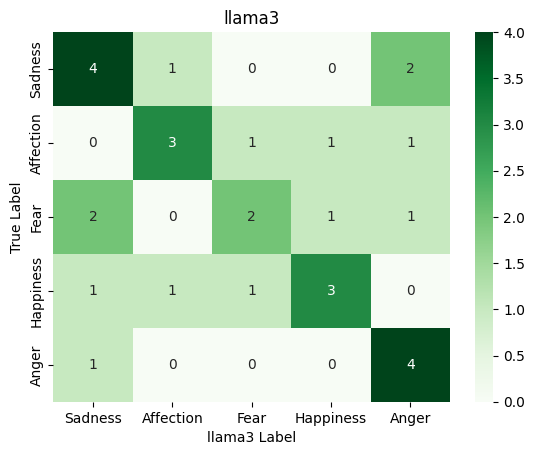

In [87]:
# llama
matrix = confusion_matrix(merged_df["label"], merged_df["label_llama3"], labels=["Sadness", "Affection", "Fear", "Happiness", "Anger"])
ax = sns.heatmap(matrix, annot=True, cmap="Greens")
ax.set(title="llama3", xlabel="llama3 Label", ylabel="True Label")
ax.xaxis.set_ticklabels(["Sadness", "Affection", "Fear", "Happiness", "Anger"])
ax.yaxis.set_ticklabels(["Sadness", "Affection", "Fear", "Happiness", "Anger"])

* Discuss your results.</br>
Obviously, the LEIA classifier is the best. The LLAMA3 classifier is not high accuracy, precision, recall, and F1 score as you can see the bar graph. It cannot classify the text whether positive or negative, for example, true label is affection, but llama3 classifies the text as anger.

* Are the models accurately predicting human emotions? </br>
According to the bar graphs,  Leia is more accurate than human, although Leia approach is not 100%.

* Which approach seems to work better? Why?</br>
Leia approach is the best. One of the reasons is that fine tuning is done by emotion self-attentions in traing phases.